In [2]:
# Анализ поведения пользователей мобильного приложения

## 1. Загрузка и первичный осмотр
#```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/user_logs.csv', parse_dates=['event_time'])
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21144 entries, 0 to 21143
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     21144 non-null  int64         
 1   event_type  21144 non-null  object        
 2   event_time  21144 non-null  datetime64[ns]
 3   group       21144 non-null  object        
 4   device      21144 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 826.1+ KB
None
   user_id    event_type          event_time group   device
0     9433          view 2023-01-01 18:05:32     B  Android
1     3202         click 2023-01-01 12:51:22     A  Android
2     4485         click 2023-01-01 01:11:34     B      iOS
3     7093          view 2023-01-01 22:59:28     A  Android
4     9373  registration 2023-01-01 07:19:54     B      iOS


In [3]:
# Удалим дубликаты (если есть)
df = df.drop_duplicates()
# Проверим пропуски
df.isnull().sum()
# Добавим дату (для агрегации)
df['date'] = df['event_time'].dt.date

In [4]:
# DAU (уникальные пользователи в день)
dau = df.groupby('date')['user_id'].nunique()
print('DAU средний:', dau.mean())

# MAU (уникальные за месяц)
mau = df['user_id'].nunique()
print('MAU:', mau)

# Stickiness (DAU/MAU)
stickiness = dau.mean() / mau
print('Stickiness:', stickiness)

DAU средний: 680.3333333333334
MAU: 8792
Stickiness: 0.07738095238095238


Воронка (абс): event_type
view            4709
click           5730
registration    3421
purchase        1971
Name: user_id, dtype: int64
Воронка (%): event_type
view            100.000000
click           121.681886
registration     72.648121
purchase         41.856020
Name: user_id, dtype: float64


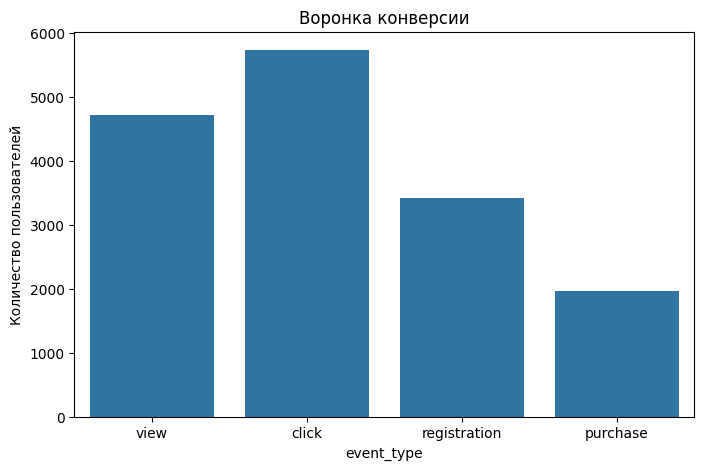

In [5]:
# События по порядку: view -> click -> registration -> purchase
# Вычислим количество уникальных пользователей, совершивших каждое событие
funnel = df.groupby('event_type')['user_id'].nunique().reindex(['view','click','registration','purchase'])
funnel_pct = funnel / funnel['view'] * 100
print('Воронка (абс):', funnel)
print('Воронка (%):', funnel_pct)

# График воронки
plt.figure(figsize=(8,5))
sns.barplot(x=funnel.index, y=funnel.values)
plt.title('Воронка конверсии')
plt.ylabel('Количество пользователей')
plt.show()

In [6]:
# Считаем конверсию для каждой группы
conv = df[df['event_type']=='purchase'].groupby('group')['user_id'].nunique()
total_users = df.groupby('group')['user_id'].nunique()
conv_rate = conv / total_users * 100
print('Конверсия в группе A:', conv_rate['A'])
print('Конверсия в группе B:', conv_rate['B'])

# Статистический тест (пропорций)
from statsmodels.stats.proportion import proportions_ztest
count = [conv['A'], conv['B']]
nobs = [total_users['A'], total_users['B']]
z_stat, p_val = proportions_ztest(count, nobs)
print('p-value:', p_val)
if p_val < 0.05:
    print('Разница статистически значима (отвергаем H0)')
else:
    print('Нет значимых различий')

# Дополнительно: бутстрап для доверительного интервала
boot_means = []
for _ in range(1000):
    sample_A = np.random.choice(df[df['group']=='A']['user_id'].unique(), size=total_users['A'], replace=True)
    sample_B = np.random.choice(df[df['group']=='B']['user_id'].unique(), size=total_users['B'], replace=True)
    conv_A = len(set(sample_A).intersection(set(df[df['event_type']=='purchase']['user_id']))) / total_users['A']
    conv_B = len(set(sample_B).intersection(set(df[df['event_type']=='purchase']['user_id']))) / total_users['B']
    boot_means.append(conv_B - conv_A)
ci_lower, ci_upper = np.percentile(boot_means, [2.5, 97.5])
print(f'95% ДИ для разницы конверсий: [{ci_lower:.4f}, {ci_upper:.4f}]')

Конверсия в группе A: 22.255125284738043
Конверсия в группе B: 22.58064516129032
p-value: 0.7144089608847812
Нет значимых различий
95% ДИ для разницы конверсий: [-0.0070, 0.0105]


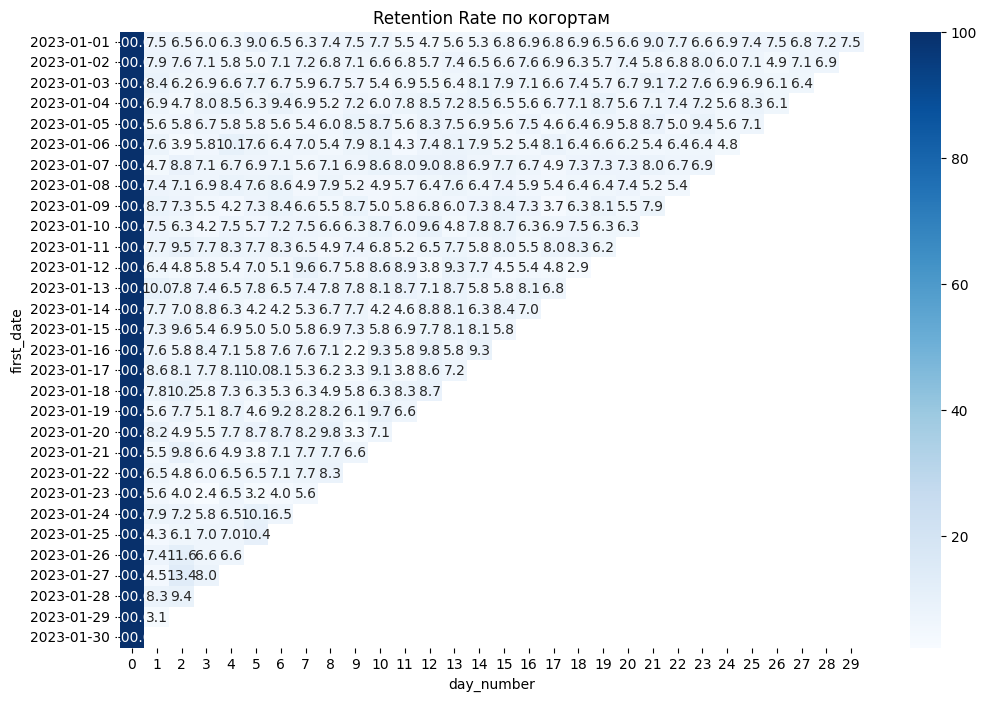

In [7]:
# Определим дату регистрации для каждого пользователя (первое событие)
first_event = df.groupby('user_id')['date'].min().rename('first_date')
df_user = df.merge(first_event, on='user_id')
# Для каждого пользователя и дня считаем, был ли он активен (любое событие)
df_user['day_number'] = (pd.to_datetime(df_user['date']) - pd.to_datetime(df_user['first_date'])).dt.days
retention = df_user.groupby(['first_date', 'day_number'])['user_id'].nunique().reset_index()
# Для каждой когорты найдём размер когорты (day_number=0)
cohort_size = retention[retention['day_number']==0].set_index('first_date')['user_id'].rename('cohort_size')
retention = retention.merge(cohort_size, left_on='first_date', right_index=True)
retention['retention_rate'] = retention['user_id'] / retention['cohort_size'] * 100

# Тепловая карта retention
pivot_ret = retention.pivot(index='first_date', columns='day_number', values='retention_rate')
plt.figure(figsize=(12,8))
sns.heatmap(pivot_ret, annot=True, fmt='.1f', cmap='Blues')
plt.title('Retention Rate по когортам')
plt.show()